In [ ]:
!pip install ultralytics

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.1/1.1 MB 32.4 MB/s eta 0:00:00


In [ ]:
import os
import zipfile
import urllib.request

BASE_DIR = "gtsrb_data"
os.makedirs(BASE_DIR, exist_ok=True)

FILES = {
    "train": "https://sid.erda.dk/public/archives/daaeac0d7ce1152aea9b61d9f1e19370/GTSRB_Final_Training_Images.zip",
    "test": "https://sid.erda.dk/public/archives/daaeac0d7ce1152aea9b61d9f1e19370/GTSRB_Final_Test_Images.zip",
    "labels": "https://sid.erda.dk/public/archives/daaeac0d7ce1152aea9b61d9f1e19370/GTSRB_Final_Test_GT.zip"
}

def download_file(url, output_path):
    if not os.path.exists(output_path):
        print(f"Downloading {url}...")
        urllib.request.urlretrieve(url, output_path)
        print("Download completed.")
    else:
        print(f"{output_path} already exists.")

def extract_zip(zip_path, extract_to):
    print(f"Extracting {zip_path}...")
    with zipfile.ZipFile(zip_path, 'r') as zip_ref:
        zip_ref.extractall(extract_to)
    print("Extraction done.")

for name, url in FILES.items():
    zip_path = os.path.join(BASE_DIR, f"{name}.zip")
    extract_path = os.path.join(BASE_DIR, name)

    download_file(url, zip_path)
    extract_zip(zip_path, extract_path)

print("\nGTSRB dataset is ready!")


Download completed.
Extracting gtsrb_data/train.zip...
Extraction done.
Download completed.
Extracting gtsrb_data/test.zip...
Extraction done.
Download completed.
Extracting gtsrb_data/labels.zip...
Extraction done.

GTSRB dataset is ready!


In [ ]:
import os
import shutil
import pandas as pd
import random
from tqdm import tqdm
from PIL import Image

# --- CONFIGURATION ---
SOURCE_DIR = "/content/gtsrb_data/train/GTSRB/Final_Training/Images"
YOLO_ROOT = "/content/datasets/gtsrb_yolo"

def setup_directories():
    if os.path.exists(YOLO_ROOT):
        shutil.rmtree(YOLO_ROOT) # Clean start

    for split in ['train', 'val']:
        os.makedirs(f"{YOLO_ROOT}/{split}/images", exist_ok=True)
        os.makedirs(f"{YOLO_ROOT}/{split}/labels", exist_ok=True)

def convert_to_yolo_bbox(bbox, width, height):
    x1, y1, x2, y2 = bbox
    w = x2 - x1
    h = y2 - y1
    x_center = x1 + (w / 2)
    y_center = y1 + (h / 2)

    # Normalize 0-1
    return x_center/width, y_center/height, w/width, h/height

def prepare_yolo_data_v2():
    setup_directories()
    print("Converting GTSRB annotations to YOLO format (with JPG conversion)...")

    class_folders = sorted([f for f in os.listdir(SOURCE_DIR) if os.path.isdir(os.path.join(SOURCE_DIR, f))])

    # Counter to verify success
    total_converted = 0

    for class_folder in tqdm(class_folders):
        folder_path = os.path.join(SOURCE_DIR, class_folder)
        csv_file = f"GT-{class_folder}.csv"
        csv_path = os.path.join(folder_path, csv_file)

        if not os.path.exists(csv_path):
            continue

        try:
            df = pd.read_csv(csv_path, sep=';')
        except Exception as e:
            print(f"Skipping CSV {csv_file}: {e}")
            continue

        for _, row in df.iterrows():
            filename = row['Filename']
            src_img_path = os.path.join(folder_path, filename)

            if not os.path.exists(src_img_path):
                continue

            # Handle column names robustly
            try:
                # Try reading uppercase or title case
                cols = df.columns
                # Find column index if exact name mismatch
                x1 = row.get('Roi.X1') or row.get('ROI.x1')
                y1 = row.get('Roi.Y1') or row.get('ROI.y1')
                x2 = row.get('Roi.X2') or row.get('ROI.x2')
                y2 = row.get('Roi.Y2') or row.get('ROI.y2')
                cls = row.get('ClassId')

                # Check for NaNs
                if pd.isna(x1) or pd.isna(y2):
                    continue

            except Exception:
                continue

            # Load Image to verify dimensions and convert to JPG (YOLO likes JPG better than PPM)
            try:
                img = Image.open(src_img_path)
                img_width, img_height = img.size
            except:
                continue # Bad image

            yolo_bbox = convert_to_yolo_bbox((x1, y1, x2, y2), img_width, img_height)

            # Setup Paths
            unique_name = f"{class_folder}_{filename.replace('.ppm', '.jpg')}"
            txt_name = unique_name.replace(".jpg", ".txt")
            split = "train" if random.random() < 0.8 else "val"

            dst_img_path = os.path.join(YOLO_ROOT, split, "images", unique_name)
            dst_txt_path = os.path.join(YOLO_ROOT, split, "labels", txt_name)

            # 1. Save Image as JPG
            img.save(dst_img_path, "JPEG")

            # 2. Save Label
            with open(dst_txt_path, 'w') as f:
                f.write(f"{int(cls)} {yolo_bbox[0]:.6f} {yolo_bbox[1]:.6f} {yolo_bbox[2]:.6f} {yolo_bbox[3]:.6f}\n")

            total_converted += 1

    print(f"\nSuccess! Converted {total_converted} images.")
    # Quick sanity check
    print("Files in train/images:", len(os.listdir(f"{YOLO_ROOT}/train/images")))

# RUN THIS CELL NOW
prepare_yolo_data_v2()

Converting GTSRB annotations to YOLO format (with JPG conversion)...


100%|██████████| 43/43 [00:24<00:00,  1.79it/s]


Success! Converted 39208 images.
Files in train/images: 31248


In [ ]:
import yaml

# Your dictionary from earlier
class_names = {
  0: "Speed limit (20 km/h)", 1: "Speed limit (30 km/h)", 2: "Speed limit (50 km/h)", 3: "Speed limit (60 km/h)",
  4: "Speed limit (70 km/h)", 5: "Speed limit (80 km/h)", 6: "End of speed limit (80 km/h)", 7: "Speed limit (100 km/h)",
  8: "Speed limit (120 km/h)", 9: "No passing", 10: "No passing for vehicles over 3.5 tons", 11: "Right-of-way at the next intersection",
  12: "Priority road", 13: "Yield", 14: "Stop", 15: "No vehicles", 16: "Vehicles over 3.5 tons prohibited",
  17: "No entry", 18: "General caution", 19: "Dangerous curve to the left", 20: "Dangerous curve to the right",
  21: "Double curve", 22: "Bumpy road", 23: "Slippery road", 24: "Road narrows on the right", 25: "Road work",
  26: "Traffic signals", 27: "Pedestrians", 28: "Children crossing", 29: "Bicycles crossing", 30: "Beware of ice/snow",
  31: "Wild animals crossing", 32: "End of all speed and passing limits", 33: "Turn right ahead", 34: "Turn left ahead",
  35: "Ahead only", 36: "Go straight or right", 37: "Go straight or left", 38: "Keep right", 39: "Keep left",
  40: "Roundabout mandatory", 41: "End of no passing", 42: "End of no passing by vehicles over 3.5 tons"
}

# Config structure
data_yaml = {
    'path': '/content/datasets/gtsrb_yolo', # Root path
    'train': 'train/images',
    'val': 'val/images',
    'nc': 43, # Number of classes
    'names': class_names # The list of names
}

# Write to file
with open('/content/gtsrb_yolo.yaml', 'w') as f:
    yaml.dump(data_yaml, f)

print("Config file gtsrb_yolo.yaml created.")

Config file gtsrb_yolo.yaml created.


In [ ]:
from ultralytics import YOLO

# 1. Load a pre-trained model (starting point)
model = YOLO('yolov8n.pt')

# 2. Train on your new Data
# imgsz=64 is small (GTSRB native), but YOLO often prefers 320 or 640.
# GTSRB are small images, so we can try 640 upscaling or keep it lower. Let's try 416 or 640.
print("Starting Training...")
model.train(
    data='/content/gtsrb_yolo.yaml',
    epochs=15,       # 15 should be enough to see amazing results
    imgsz=416,       # Image size for training
    batch=32,
    name='gtsrb_yolo_run'
)

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
Starting Training...
Ultralytics 8.3.234 🚀 Python-3.12.12 torch-2.9.0+cu126 CUDA:0 (Tesla T4, 15095MiB)
engine/trainer: agnostic_nms=False, amp=True, augment=False, auto_augment=randaugment, batch=32, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/gtsrb_yolo.yaml, degrees=0.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, epochs=15, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=416, int8=False,

ultralytics.utils.metrics.DetMetrics object with attributes:

ap_class_index: array([ 0,  1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37, 38, 39, 40, 41, 42])
box: ultralytics.utils.metrics.Metric object
confusion_matrix: <ultralytics.utils.metrics.ConfusionMatrix object at 0x7a32306712b0>
curves: ['Precision-Recall(B)', 'F1-Confidence(B)', 'Precision-Confidence(B)', 'Recall-Confidence(B)']
curves_results: [[array([          0,    0.001001,    0.002002,    0.003003,    0.004004,    0.005005,    0.006006,    0.007007,    0.008008,    0.009009,     0.01001,    0.011011,    0.012012,    0.013013,    0.014014,    0.015015,    0.016016,    0.017017,    0.018018,    0.019019,     0.02002,    0.021021,    0.022022,    0.023023,
          0.024024,    0.025025,    0.026026,    0.027027,    0.028028,    0.029029,     0.03003,    0.031031,    0.032032,    0.033033,    0.034034,    0.035035,    0.03


0: 416x416 1 Speed limit (50 km/h), 8.2ms
1: 416x416 (no detections), 8.2ms
2: 416x416 1 Speed limit (60 km/h), 8.2ms
3: 416x416 (no detections), 8.2ms
4: 416x416 (no detections), 8.2ms
Speed: 1.2ms preprocess, 8.2ms inference, 0.5ms postprocess per image at shape (1, 3, 416, 416)
File: 50km.png


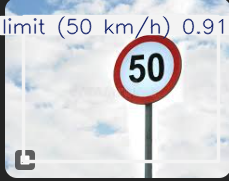

File: End of no passing.jpg


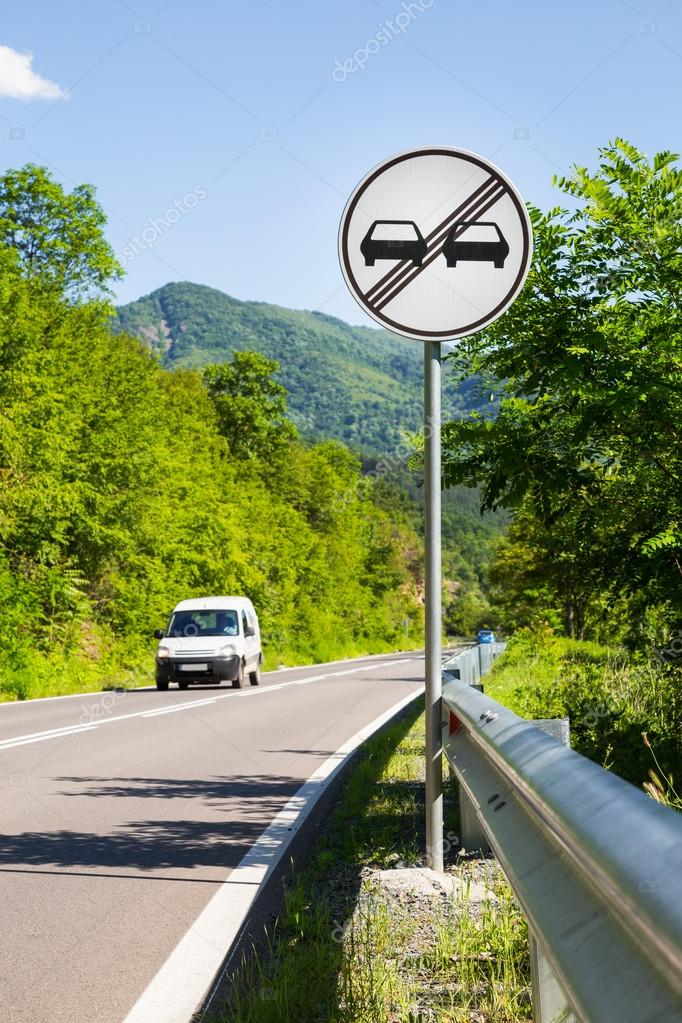

File: 40.jpg


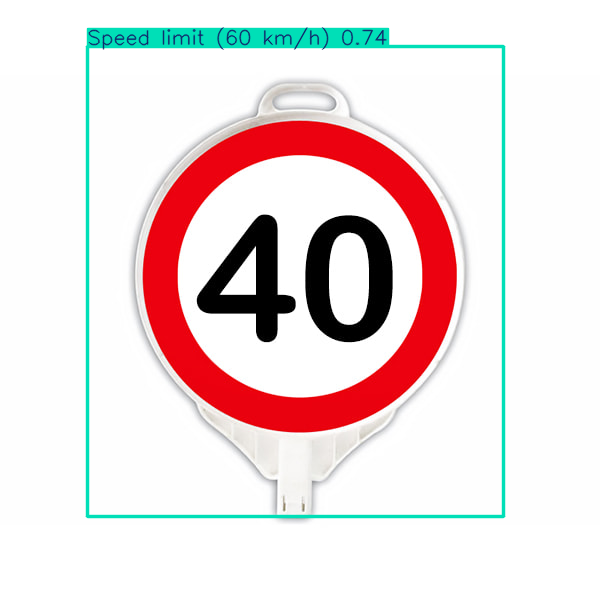

File: yield.jpg


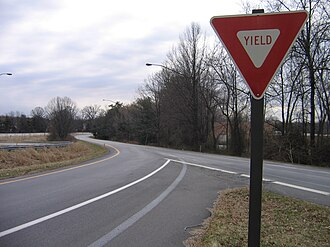

File: 80km.png


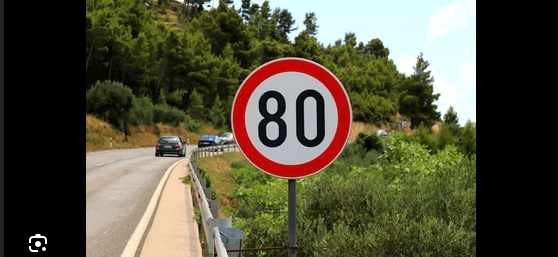

In [ ]:
import glob
from IPython.display import display
from PIL import Image

# 1. Run inference on your test images
test_images = ["50km.png", "End of no passing.jpg", "40.jpg", "yield.jpg", "80km.png"]

# Perform prediction
results = model.predict(test_images, conf=0.25)

# 2. Show results
for r in results:
    # Plot results on the image (draws the box and label automatically)
    im_array = r.plot()  # plot a BGR numpy array of predictions
    im = Image.fromarray(im_array[..., ::-1])  # RGB PIL image

    print(f"File: {r.path}")
    display(im)